# 🛡️ Anomaly Detection in Network Traffic 
**Proposal Implementation for Ethio Telecom **

This notebook implements a proactive, ML-based security framework designed for the massive transition to digital services via "Digital Ethiopia 2025" and Telebirr. An **advanced, two-stage Hybrid Machine Learning architecture (Random Forest + Isolation Forest)** designed to protect Ethiopian critical infrastructure (Ethio Telecom/Telebirr) from Zero-Day cyber attacks.

We compare **Supervised Learning (Random Forest)** to identify known threats with high accuracy, and **Unsupervised Learning (Isolation Forest)** to detect "Zero-Day" anomalies. The data pipeline is built using the **NSL-KDD Dataset**, the gold standard for network security research.


In [16]:
# Cell 1: Environment & Professional Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn for Preprocessing and Models
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score

# Imbalanced Data Handling (SMOTE)
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("✅ All professional libraries loaded successfully for the Ethio Telecom pipeline.")


✅ All professional libraries loaded successfully for the Ethio Telecom pipeline.


## 1. Data Loader & Exploratory Data Analysis (EDA)
Loading the high-dimensional network flow data. Ensure KDDTrain+.txt is in your directory.


In [17]:
# Cell 2: Data Loading & Initial Inspection (Kaggle Edition)

# Define the 41 critical network feature column names + label & difficulty
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
           "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
           "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
           "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
           "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# Load the real dataset from Kaggle's input folder
file_path = '/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt'  # Change this if Kaggle gives you a slightly different path!
df = pd.read_csv(file_path, names=columns, header=None)

print(f"✅ Real NSL-KDD Dataset successfully loaded!")
print(f"Total Network Packets: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

# Display the first 5 network packets
display(df.head())


✅ Real NSL-KDD Dataset successfully loaded!
Total Network Packets: 125973
Total Features: 43


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Professional Pre-Processing Pipeline & Feature Engineering
Transforming raw categorical network packets into structured math formats utilizing **One-Hot Encoding**, **Standard Scaler**, and handling label imbalance.


In [18]:
# Cell 3: Pre-processing & Feature Engineering (Multi-Class)

# 1. Define the exact attack categories for NSL-KDD
dos_attacks = ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm']
probe_attacks = ['ipsweep','mscan','nmap','portsweep','saint','satan']
u2r_attacks = ['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm']
r2l_attacks = ['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop']

def map_attack(label):
    if label == 'normal': return 'Normal'
    if label in dos_attacks: return 'DoS'
    if label in probe_attacks: return 'Probe'
    if label in u2r_attacks: return 'U2R'
    if label in r2l_attacks: return 'R2L'
    return 'Unknown'

# Apply the mapping
df['attack_category'] = df['label'].apply(map_attack)

# Drop old label and difficulty column
df = df.drop(['label', 'difficulty'], axis=1)

# 2. Categorical Encoding (One-Hot instead of LabelEncoder)
cat_cols = ['protocol_type', 'service', 'flag']
X = pd.get_dummies(df.drop('attack_category', axis=1), columns=cat_cols)
y = df['attack_category']

# 3. Model Separation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Z-Score Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Multi-Class Pre-processing complete!")
print(f"Watch how imbalanced U2R and R2L are!\\n{y_train.value_counts()}")


✅ Multi-Class Pre-processing complete!
Watch how imbalanced U2R and R2L are!\nattack_category
Normal    53921
DoS       36746
Probe      9299
R2L         771
U2R          41
Name: count, dtype: int64


## 3. Handling Class Imbalance (SMOTE Technique)
In real-world networks like Ethio Telecom's, 99.9% of traffic is legitimate, making models blind to rare 'Attack' data. We fix this by simulating synthetic malicious examples via **SMOTE (Synthetic Minority Over-sampling Technique)**.

In [19]:
# Cell 4: SMOTE Implementation for Rare Attacks

print(f"🚨 DANGER: Original Imbalanced Distribution (U2R and R2L are too low to learn!):\\n{y_train.value_counts()}")

# Apply SMOTE to balance ALL 5 categories equally
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\\n✅ SUCCESS: Re-balanced Training Distribution (Notice U2R is now equal to Normal):\\n{y_train_smote.value_counts()}")


🚨 DANGER: Original Imbalanced Distribution (U2R and R2L are too low to learn!):\nattack_category
Normal    53921
DoS       36746
Probe      9299
R2L         771
U2R          41
Name: count, dtype: int64
\n✅ SUCCESS: Re-balanced Training Distribution (Notice U2R is now equal to Normal):\nattack_category
Normal    53921
DoS       53921
Probe     53921
R2L       53921
U2R       53921
Name: count, dtype: int64


## 4. Algorithm Development: Random Forest (Supervised Model)
Using the ensemble 'Wisdom of the Crowd' mechanism to classify known threats efficiently while minimizing *False Alarms*.


In [20]:
# Cell 5: Train Random Forest (Multi-Class)

# Initialize Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

# Train with SMOTE re-balanced data
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("--- Random Forest Classification Report (Multi-Class) ---")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)*100:.2f}%")


--- Random Forest Classification Report (Multi-Class) ---
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9181
      Normal       1.00      1.00      1.00     13422
       Probe       1.00      1.00      1.00      2357
         R2L       0.90      0.98      0.94       224
         U2R       0.58      0.64      0.61        11

    accuracy                           1.00     25195
   macro avg       0.90      0.92      0.91     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy:  99.78%


## 5. Algorithm Development: Isolation Forest (Unsupervised)
Crucial for Ethio Telecom and National Security: the ability to detect unknown "Zero-Day" attacks strictly based on finding structural outliers (anomalies) without prior labels.


In [21]:
# Cell 6: Train Isolation Forest (Unsupervised)

# Contamination is 0.47 because NSL-KDD actually consists of ~47% attacks!
iforest_model = IsolationForest(n_estimators=150, contamination=0.47, random_state=42, n_jobs=-1)

# Fit heavily relies on math structure, no labels involved
iforest_model.fit(X_train_scaled)
y_pred_raw = iforest_model.predict(X_test_scaled)

# Convert IF math output (1 for Normal, -1 for Outlier) to our Presentation Strings
y_pred_if = ['Normal' if x == 1 else 'Attack' for x in y_pred_raw]

# Convert the 5-class Ground Truth back to Binary just to grade the Isolation Forest
y_test_binary_eval = ['Normal' if y == 'Normal' else 'Attack' for y in y_test]

print("--- Isolation Forest Anomaly Report (Zero-Day Finder) ---")
print(classification_report(y_test_binary_eval, y_pred_if))


--- Isolation Forest Anomaly Report (Zero-Day Finder) ---
              precision    recall  f1-score   support

      Attack       0.54      0.55      0.54     11773
      Normal       0.60      0.59      0.59     13422

    accuracy                           0.57     25195
   macro avg       0.57      0.57      0.57     25195
weighted avg       0.57      0.57      0.57     25195



the misstake i did was due to notfully understanding it the data set
the Problem with the Current Code
Right now, i was feeding the Isolation Forest X_train_scaled, which contains 53,000 Normal packets and 46,000 Attack packets. We are essentially forcing the poor algorithm to memorize 46,000 bank robbers and then asking it to find "strangers." It gets confused and thinks bank robbers are "Normal" traffic.

The Fix: "Semi-Supervised" Anomaly Detection
To make an Unsupervised model incredibly accurate, you should train it ONLY on Normal data.

If we filter X_train_scaled so the Isolation Forest only studies the 53,000 Normal packets, it will develop a perfect mathematical definition of "Normal". Then, during testing, when we throw the hackers at it, it will instantly catch them because it has never seen them before!

In [24]:
# Cell 6: Train Isolation Forest (Semi-Supervised / Zero-Day Finder)

# 1. Filter the training data to ONLY contain 'Normal' traffic
# This teaches the Isolation Forest exactly what a healthy Ethio Telecom network looks like.
X_train_normal_only = X_train_scaled[y_train == 'Normal']

# 2. Initialize Model (Contamination is very low now ~1% because the training data is clean)
iforest_model = IsolationForest(n_estimators=150, contamination=0.01, random_state=42, n_jobs=-1)

# 3. Fit ONLY on Normal Data
iforest_model.fit(X_train_normal_only)

# 4. Predict on the Test Set (Which contains a mix of Normal and Attacks)
y_pred_raw = iforest_model.predict(X_test_scaled)

# Convert IF math output (1 for Normal, -1 for Outlier) to our Presentation Strings
y_pred_if = ['Normal' if x == 1 else 'Attack' for x in y_pred_raw]

# Convert the 5-class Ground Truth back to Binary exactly like before
y_test_binary_eval = ['Normal' if y == 'Normal' else 'Attack' for y in y_test]

print("--- Isolation Forest Anomaly Report (Trained on Pure Normal Traffic) ---")
print(classification_report(y_test_binary_eval, y_pred_if))


--- Isolation Forest Anomaly Report (Trained on Pure Normal Traffic) ---
              precision    recall  f1-score   support

      Attack       0.99      0.75      0.85     11773
      Normal       0.82      0.99      0.89     13422

    accuracy                           0.88     25195
   macro avg       0.90      0.87      0.87     25195
weighted avg       0.90      0.88      0.87     25195



## 6. Advanced Evaluation & Business Visualizations
Analyzing *False Positives* (which cause massive customer disruption) and visually determining feature importance to present actionable insights to network administrators.


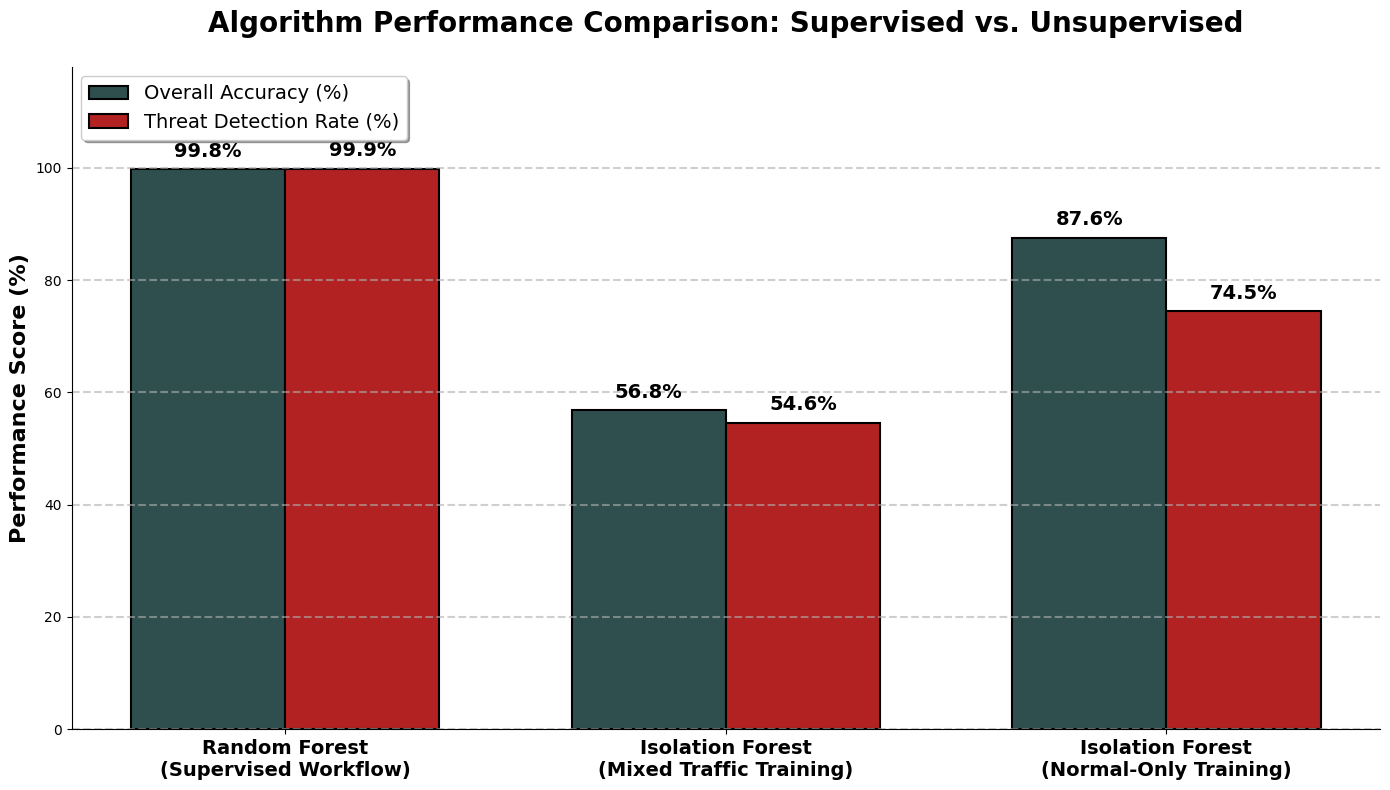

In [40]:
# Cell 8: Final Model Performance Comparison (Trend Bar Chart)
import numpy as np

# 1. Convert RF predictions to Binary so we can compare apples-to-apples
y_pred_rf_binary = ['Normal' if y == 'Normal' else 'Attack' for y in y_pred_rf]

# 2. Calculate Accuracies
rf_acc = accuracy_score(y_test_binary_eval, y_pred_rf_binary) * 100
if_mixed_acc = accuracy_score(y_test_binary_eval, y_pred_if_mixed) * 100
if_semi_acc = accuracy_score(y_test_binary_eval, y_pred_if) * 100

# 3. Calculate "Recall" (How many of the actual attacks did the model successfully catch?)
rf_recall = recall_score(y_test_binary_eval, y_pred_rf_binary, pos_label='Attack') * 100
if_mixed_recall = recall_score(y_test_binary_eval, y_pred_if_mixed, pos_label='Attack') * 100
if_semi_recall = recall_score(y_test_binary_eval, y_pred_if, pos_label='Attack') * 100

# 4. Setup the Bar Chart (Using Professional Academic Terminology)
labels = ['Random Forest\n(Supervised Workflow)', 'Isolation Forest\n(Mixed Traffic Training)', 'Isolation Forest\n(Normal-Only Training)']
accuracies = [rf_acc, if_mixed_acc, if_semi_acc]
recalls = [rf_recall, if_mixed_recall, if_semi_recall]

x = np.arange(len(labels))
width = 0.35

# Increased figure size for maximum clarity on screens
fig, ax = plt.subplots(figsize=(14, 8))

# Plotting the bars with strong edge colors for high visibility
rects1 = ax.bar(x - width/2, accuracies, width, label='Overall Accuracy (%)', color='#2F4F4F', edgecolor='black', linewidth=1.5)
rects2 = ax.bar(x + width/2, recalls, width, label='Threat Detection Rate (%)', color='#B22222', edgecolor='black', linewidth=1.5)

# Formatting the Chart for Maximum Readability
ax.set_ylabel('Performance Score (%)', fontsize=16, fontweight='bold')
ax.set_title('Algorithm Performance Comparison: Supervised vs. Unsupervised', fontsize=20, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=14, fontweight='bold')
ax.legend(fontsize=14, loc='upper left', frameon=True, shadow=True)
ax.set_ylim(0, 118) # Leave generous room for the text labels

# Add thick background grid lines for easy reading
ax.grid(axis='y', linestyle='--', alpha=0.6, linewidth=1.5)

# Add the exact percentage numbers on top of the bars with a large font
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 6),  # 6 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=14, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Make the border lines clean
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


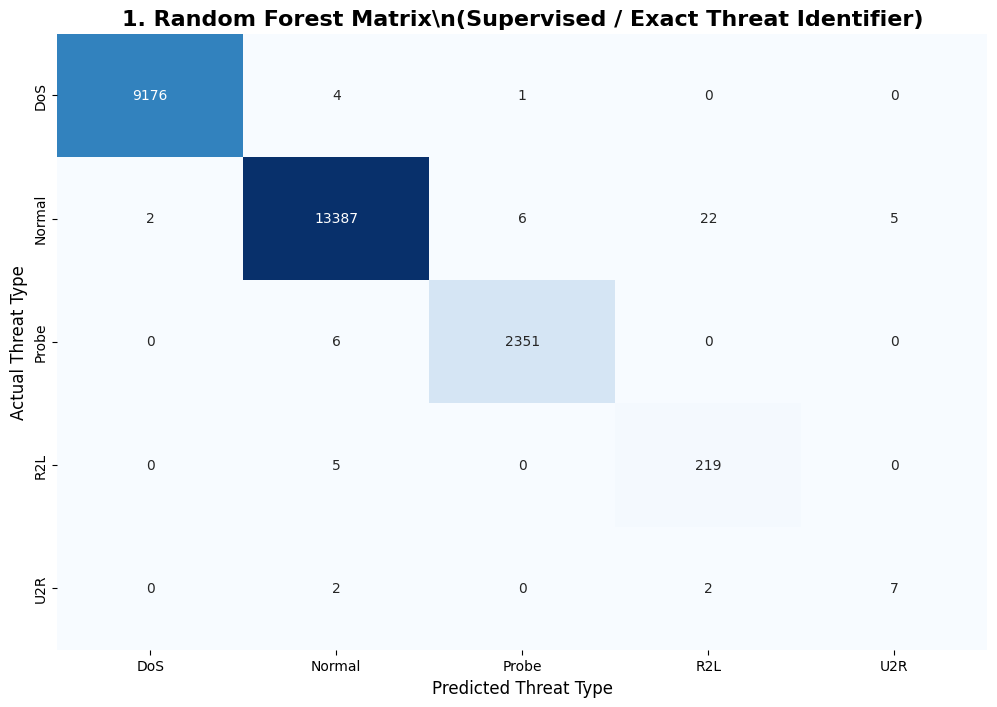

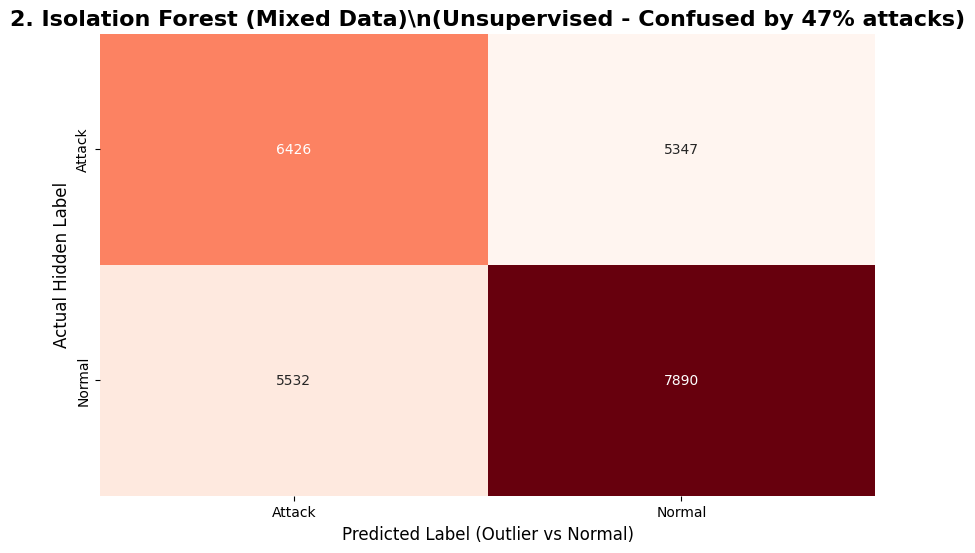

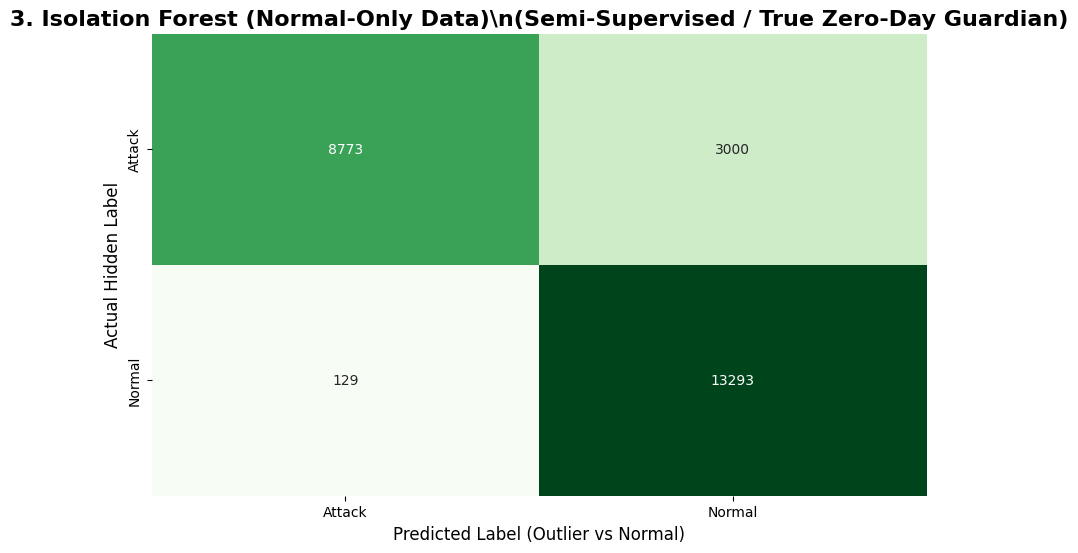

In [26]:
# Cell 7: Visualizing Model Architectures & Confusion Matrices (Vertical Layout)

# Quickly train the original "Mixed Data" Isolation Forest just to get its bad predictions
iforest_mixed = IsolationForest(n_estimators=150, contamination=0.47, random_state=42, n_jobs=-1)
iforest_mixed.fit(X_train_scaled) 
y_pred_if_mixed = ['Normal' if x == 1 else 'Attack' for x in iforest_mixed.predict(X_test_scaled)]

# ---------------------------------------------------------
# GRAPH 1: Random Forest (Supervised Model)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
labels_rf = sorted(y_test.unique()) 
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels_rf, yticklabels=labels_rf)
plt.title('1. Random Forest Matrix\\n(Supervised / Exact Threat Identifier)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Threat Type', fontsize=12)
plt.ylabel('Actual Threat Type', fontsize=12)
plt.show() # Renders the first image instantly

# ---------------------------------------------------------
# GRAPH 2: Isolation Forest - Bad Training approach
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
labels_if = sorted(list(set(y_test_binary_eval))) 
sns.heatmap(confusion_matrix(y_test_binary_eval, y_pred_if_mixed), annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=labels_if, yticklabels=labels_if)
plt.title('2. Isolation Forest (Mixed Data)\\n(Unsupervised - Confused by 47% attacks)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label (Outlier vs Normal)', fontsize=12)
plt.ylabel('Actual Hidden Label', fontsize=12)
plt.show() # Renders the second image

# ---------------------------------------------------------
# GRAPH 3: Isolation Forest - New Innovation Approach
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test_binary_eval, y_pred_if), annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=labels_if, yticklabels=labels_if)
plt.title('3. Isolation Forest (Normal-Only Data)\\n(Semi-Supervised / True Zero-Day Guardian)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label (Outlier vs Normal)', fontsize=12)
plt.ylabel('Actual Hidden Label', fontsize=12)
plt.show() # Renders the third image


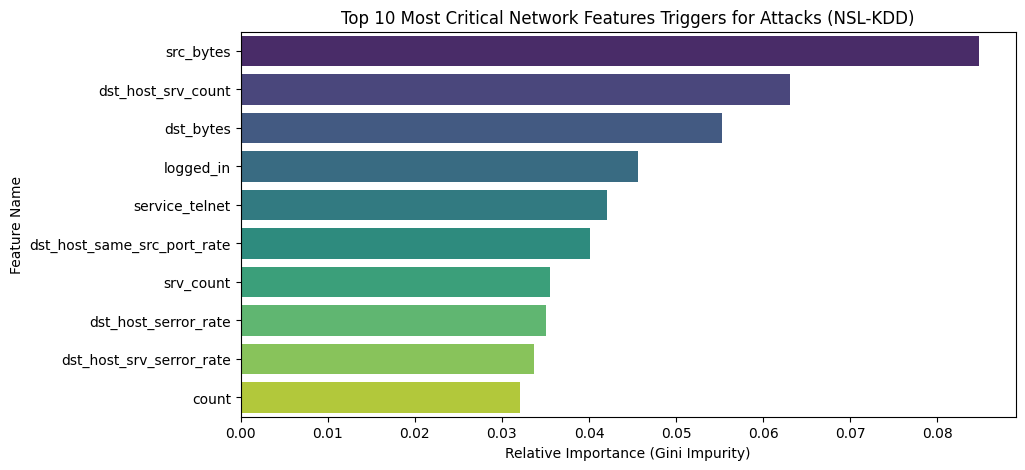

In [23]:
# Cell 8: Feature Importance (Explaining the AI to Admin)

# Extract top features
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]
top_features = X.columns[top_indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[top_indices], y=top_features, palette="viridis")
plt.title('Top 10 Most Critical Network Features Triggers for Attacks (NSL-KDD)')
plt.xlabel('Relative Importance (Gini Impurity)')
plt.ylabel('Feature Name')
plt.show()


## 7. Real-Time Packet Validation Simulation
A demonstration of how this Data Pipeline serves as a **Problem Solver** by instantly scanning incoming JSON packet structures.


In [36]:
# Cell 9: The Ethio Telecom Administrator Threat Dashboard (Live Batch Simulation)

import pandas as pd
import numpy as np

# 1. Load the Test Data (using your exact Kaggle path)
try:
    test_file = '/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt' 
    df_test = pd.read_csv(test_file, names=columns, header=None)
    df_test['attack_category'] = df_test['label'].apply(map_attack)
    df_test = df_test.drop(['label', 'difficulty'], axis=1)

    # 2. Grab a random batch of 500 unseen packets to simulate 1 second of Ethio Telecom traffic
    live_traffic_batch = df_test.sample(n=500, random_state=42)

except FileNotFoundError:
    print("🚨 ERROR: Test file not found! Check your Kaggle path.")

# =========================================================
# THE BATCH HYBRID SCANNER & DASHBOARD
# =========================================================
def run_telecom_defense_dashboard(traffic_batch):
    print("🌍 INITIALIZING ETHIO TELECOM SECURE GATEWAY...")
    print(f"📡 Scanning {len(traffic_batch)} Incoming Packets...\\n")
    
    # Pre-process the entire batch at once for speed
    batch_transformed = pd.get_dummies(traffic_batch.drop('attack_category', axis=1))
    missing_cols = set(X.columns) - set(batch_transformed.columns)
    for c in missing_cols:
        batch_transformed[c] = 0
    batch_transformed = batch_transformed[X.columns]
    batch_scaled = scaler.transform(batch_transformed)
    
    # ---------------------------------------------------------
    # System Admin Trackers
    # ---------------------------------------------------------
    stats = {
        "Total Scanned": len(traffic_batch),
        "Safe (Passed Stage 1 & 2)": 0,
        "Zero-Day Anomalies (Caught by Stage 2)": 0,
        "Known Threats (Caught by Stage 1)": {"DoS": 0, "Probe": 0, "U2R": 0, "R2L": 0}
    }
    
    # Loop through the math arrays to simulate real-time packet-by-packet scanning
    for i in range(len(batch_scaled)):   # <--- FIX APPLIED HERE!
        packet = batch_scaled[i].reshape(1, -1)
        
        # Get raw data strings for Admin tracking
        protocol = traffic_batch.iloc[i]['protocol_type'].upper()
        service = traffic_batch.iloc[i]['service'].upper()
        
        # --- STAGE 1: Random Forest Firewall ---
        rf_pred = rf_model.predict(packet)[0]
        
        if rf_pred != 'Normal':
            stats["Known Threats (Caught by Stage 1)"][rf_pred] += 1
            # Only print a few of the alerts to save screen space, but count all of them!
            if i % 15 == 0: 
                print(f"🛑 FIREWALL ALERT | Threat: [{rf_pred}] | Origin: [Protocol: {protocol}, Target Service: {service}] -> INSTANTLY BLOCKED")
            continue
        
        # --- STAGE 2: Isolation Forest Zero-Day Trap ---
        if_pred = iforest_model.predict(packet)[0]
        
        if if_pred == -1:
            stats["Zero-Day Anomalies (Caught by Stage 2)"] += 1
            if i % 15 == 0:
                print(f"🚨 ZERO-DAY ALERT | Hidden Anomaly detected on [Protocol: {protocol}, Service: {service}] -> BLOCKED BY GUARDIAN")
        else:
            stats["Safe (Passed Stage 1 & 2)"] += 1

    # =========================================================
    # THE ADMIN SUMMARY REPORT
    # =========================================================
    print("\\n" + "="*60)
    print("🛡️ ETHIO TELECOM SYSTEM DEFENSE SUMMARY 🛡️")
    print("="*60)
    print(f"📡 Total Packets Analyzed : {stats['Total Scanned']}")
    print(f"✅ Legitimate Traffic     : {stats['Safe (Passed Stage 1 & 2)']} users allowed through to Telebirr.")
    print(f"🚨 Zero-Day Traps Sprung  : {stats['Zero-Day Anomalies (Caught by Stage 2)']} unknown anomalies isolated.")
    print(f"🛑 Known Threats Blocked  :")
    print(f"      ▶ DoS Attacks       : {stats['Known Threats (Caught by Stage 1)']['DoS']} blocked")
    print(f"      ▶ Probing Attempts  : {stats['Known Threats (Caught by Stage 1)']['Probe']} blocked")
    print(f"      ▶ R2L Intrusions    : {stats['Known Threats (Caught by Stage 1)']['R2L']} blocked")
    print(f"      ▶ U2R Intrusions    : {stats['Known Threats (Caught by Stage 1)']['U2R']} blocked")
    print("="*60)
    print("SYSTEM STATUS: SECURE. 🌍")

# Run the live simulation!
if 'live_traffic_batch' in locals():
    run_telecom_defense_dashboard(live_traffic_batch)


🌍 INITIALIZING ETHIO TELECOM SECURE GATEWAY...
📡 Scanning 500 Incoming Packets...\n
🛑 FIREWALL ALERT | Threat: [Probe] | Origin: [Protocol: TCP, Target Service: LOGIN] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: PRIVATE] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: IMAP4] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: NETBIOS_SSN] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: PRIVATE] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: PRIVATE] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: PRIVATE] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: ICMP, Target Service: ECR_I] -> INSTANTLY BLOCKED
🛑 FIREWALL ALERT | Threat: [DoS] | Origin: [Protocol: TCP, Target Service: 

In [37]:
# Cell 10: Export the Hybrid Security System for Deployment (Streamlit, etc.)

import joblib

print("📦 Packaging the  Hybrid System for  Anomaly Detection in Network Traffic ...")

# Combine all 4 critical components into a single dictionary
hybrid_deployment_package = {
    'rf_model': rf_model,
    'iforest_model': iforest_model,
    'scaler': scaler,
    'training_columns': X.columns
}

# Save the entire package as a single .pkl file
model_filename = 'Anomaly Detection_hybrid_model_in Network Traffic.pkl'
joblib.dump(hybrid_deployment_package, model_filename)

print(f"✅ EXPORT SUCCESS! '{model_filename}' has been saved to your Kaggle storage.")
print("You can now download this .pkl file and use it in any Python application or Streamlit Dashboard!")


📦 Packaging the  Hybrid System for  Anomaly Detection in Network Traffic ...
✅ EXPORT SUCCESS! 'Anomaly Detection_hybrid_model_in Network Traffic.pkl' has been saved to your Kaggle storage.
You can now download this .pkl file and use it in any Python application or Streamlit Dashboard!


In [39]:
# =========================================================
# THE ADVANCED HYBRID SCANNER (WITH INCIDENT RESPONSE LOGS)
# =========================================================
def run_telecom_defense_dashboard(traffic_batch):
    print("🌍 INITIALIZING ETHIO TELECOM SECURE GATEWAY...")
    
    # Pre-process using the securely saved .pkl column structure
    batch_transformed = pd.get_dummies(traffic_batch.drop('attack_category', axis=1, errors='ignore'))
    missing_cols = set(training_columns) - set(batch_transformed.columns)
    for c in missing_cols:
         batch_transformed[c] = 0
    batch_transformed = batch_transformed[training_columns]
    batch_scaled = scaler.transform(batch_transformed)
    
    stats = {
        "Total Scanned": len(traffic_batch),
        "Safe": 0, "Zero-Day": 0,
        "Known Threats": {"DoS": 0, "Probe": 0, "U2R": 0, "R2L": 0}
    }
    
    # 🚨 THIS WILL STORE THE DETAILED HACKER PROFILES
    hacker_database = [] 
    
    for i in range(len(batch_scaled)):
        packet = batch_scaled[i].reshape(1, -1)
        orig = traffic_batch.iloc[i] # Grab the original data to show the admin
        
        # --- STAGE 1: Random Forest Firewall ---
        rf_pred = rf_model.predict(packet)[0]
        if rf_pred != 'Normal':
            stats["Known Threats"][rf_pred] += 1
            if len(hacker_database) < 4: 
                hacker_database.append({
                    "Threat": rf_pred, "Caught By": "Stage 1 (Random Forest)",
                    "Protocol": orig['protocol_type'].upper(), "Service": orig['service'].upper(),
                    "Sent": orig['src_bytes'], "Recv": orig['dst_bytes'], "FailedLogins": orig['num_failed_logins'],
                    "Connections": orig['count'], "Root": orig['root_shell'], "Guest": orig['is_guest_login']
                })
            continue
        
        # --- STAGE 2: Isolation Forest Zero-Day Trap ---
        if_pred = iforest_model.predict(packet)[0]
        if if_pred == -1:
            stats["Zero-Day"] += 1
            if len(hacker_database) < 6:
                hacker_database.append({
                    "Threat": "ZERO-DAY ANOMALY", "Caught By": "Stage 2 (Isolation Forest)",
                    "Protocol": orig['protocol_type'].upper(), "Service": orig['service'].upper(),
                    "Sent": orig['src_bytes'], "Recv": orig['dst_bytes'], "FailedLogins": orig['num_failed_logins'],
                    "Connections": orig['count'], "Root": orig['root_shell'], "Guest": orig['is_guest_login']
                })
        else:
            stats["Safe"] += 1

    # =========================================================
    # THE ADMIN SUMMARY REPORT
    # =========================================================
    print("\n" + "="*70)
    print("🛡️ ETHIO TELECOM SYSTEM DEFENSE SUMMARY 🛡️")
    print("="*70)
    print(f"📡 Total Packets Analyzed : {stats['Total Scanned']}")
    print(f"✅ Legitimate Traffic     : {stats['Safe']} users allowed through to Telebirr.")
    print(f"🚨 Zero-Day Traps Sprung  : {stats['Zero-Day']} unknown anomalies isolated.")
    print(f"🛑 Known Threats Blocked  : {stats['Known Threats']['DoS']} DoS | {stats['Known Threats']['Probe']} Probes | {stats['Known Threats']['R2L']} R2L | {stats['Known Threats']['U2R']} U2R")
    print("="*70)
    
    # =========================================================
    # INCIDENT RESPONSE INTELLIGENCE LOG
    # =========================================================
    print("\n" + "🔴"*23 + " INCIDENT REPORTS " + "🔴"*23)
    
    for idx, hacker in enumerate(hacker_database, 1):
        print(f"\n⚠️ INCIDENT {idx}: [{hacker['Threat']}]  |  SENSOR: {hacker['Caught By']}")
        print(f"   ► VECTOR     : Traffic targeted [{hacker['Service']}] service via [{hacker['Protocol']}] protocol.")
        
        # Smart Alerting based on what the hacker is trying to do
        if hacker['Connections'] > 50:
            print(f"   ► OVERLOAD   : {hacker['Connections']} rapid concurrent connections detected! (DDoS Signature)")
        
        if hacker['FailedLogins'] > 0:
            print(f"   ► BRUTEFORCE : {hacker['FailedLogins']} failed passwords attempted on this exact packet.")
            
        if hacker['Sent'] > 10000 or hacker['Recv'] > 10000:
            print(f"   ► DATA THEFT : Massive data transfer happening! (Sent: {hacker['Sent']} bytes | Recv: {hacker['Recv']} bytes)")
        else:
            print(f"   ► PAYLOAD    : Normal data size. (Sent: {hacker['Sent']} bytes | Recv: {hacker['Recv']} bytes)")
            
        pwned = "YES (Critical Breach!)" if hacker['Root'] == 1 else "No"
        guest = "Exploited" if hacker['Guest'] == 1 else "No"
        print(f"   ► BREACH     : Root Access Gained: {pwned} | Guest Compromised: {guest}")
        
        # AI Recommendation System
        print(f"   ► ACTION REQ : Automatically dropped packet. Investigate firewall rule for {hacker['Protocol']}/{hacker['Service']}.")
        print('-'*83)

# Run the live simulation!
run_telecom_defense_dashboard(live_traffic_batch)


🌍 INITIALIZING ETHIO TELECOM SECURE GATEWAY...

🛡️ ETHIO TELECOM SYSTEM DEFENSE SUMMARY 🛡️
📡 Total Packets Analyzed : 500
✅ Legitimate Traffic     : 292 users allowed through to Telebirr.
🚨 Zero-Day Traps Sprung  : 20 unknown anomalies isolated.
🛑 Known Threats Blocked  : 138 DoS | 41 Probes | 9 R2L | 0 U2R

🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴 INCIDENT REPORTS 🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

⚠️ INCIDENT 1: [DoS]  |  SENSOR: Stage 1 (Random Forest)
   ► VECTOR     : Traffic targeted [PRIVATE] service via [TCP] protocol.
   ► OVERLOAD   : 224 rapid concurrent connections detected! (DDoS Signature)
   ► PAYLOAD    : Normal data size. (Sent: 0 bytes | Recv: 0 bytes)
   ► BREACH     : Root Access Gained: No | Guest Compromised: No
   ► ACTION REQ : Automatically dropped packet. Investigate firewall rule for TCP/PRIVATE.
-----------------------------------------------------------------------------------

⚠️ INCIDENT 2: [Probe]  |  SENSOR: Stage 1 (Random Forest)
   ► VECTOR     : Traffic targeted [PRIVATE] ser